In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_201112, pict_calibration
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
import cv2
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
#PATHの読み込み
intensity_path = []
lifetime_path = []
files = glob.glob('/Users/masaharu/Desktop/執筆論文/温度ダイナミクス論文/Fig4/Fig4b/110mW_5sec_50rep_cell05/110mW_5sec_50rep_3_110mW_5sec_50rep_3_?/')
files.sort()
for file in files:
    path = glob.glob(file + '/*ch00.tif')
    path.sort()
    intensity_path += path
    path = glob.glob(file + '/*ch01.tif')
    path.sort()    
    lifetime_path += path

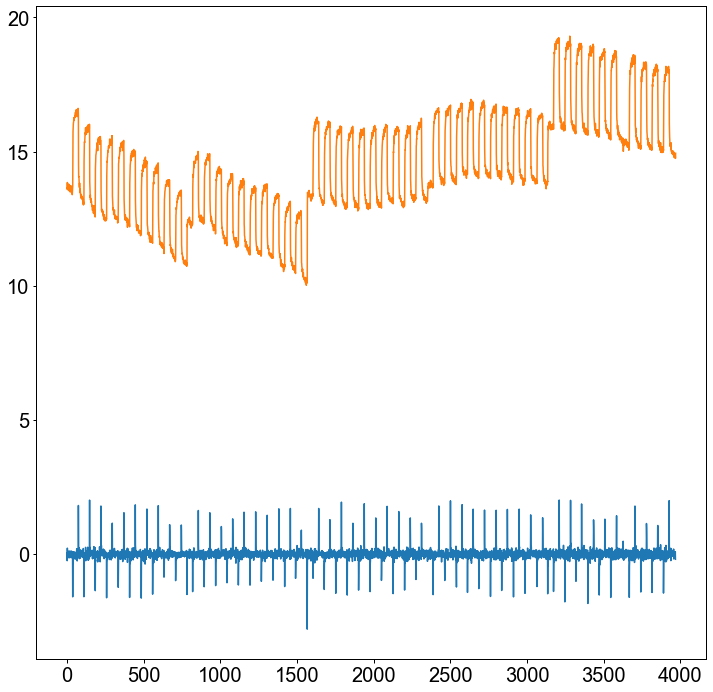

In [3]:
#IRレーザーがoffになるタイミングを探す
int_mean = []

for files in intensity_path:


    #加熱中心の強度変化
    int_image = np.array(Image.open(files))
    mean = np.mean(int_image)
    int_mean.append(mean)

diff = np.array(int_mean)[:-1] - np.array(int_mean)[1:]

#体裁調整
plt.figure(figsize = (12, 12))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams["font.size"] = 20

off_index = pd.DataFrame(diff)
off_index = np.ravel(off_index[off_index[0] > 0.7].index)

plt.plot(diff)
plt.plot(int_mean)
plt.show()


off_index_corrected = []
for index in off_index:
    max_index = pd.DataFrame(diff)[index - 5: index + 5][0].idxmax()
    off_index_corrected.append(max_index)
off_index_corrected = pd.DataFrame(off_index_corrected).drop_duplicates()

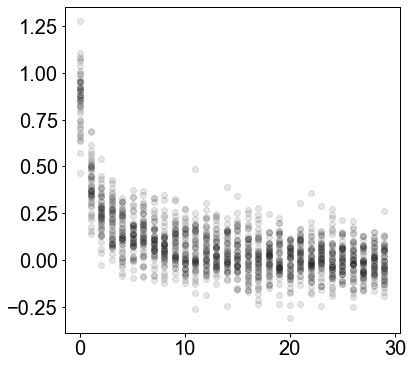

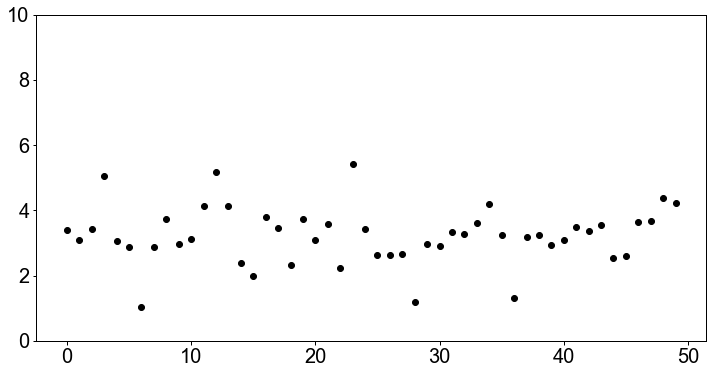

In [9]:
plt.figure(figsize = (6, 6))
AUC = []
masking = np.array(Image.open('/Users/masaharu/Desktop/執筆論文/温度ダイナミクス論文/Fig4/Fig4b/110mW_5sec_50rep_cell05/masking.tif'))
for index in off_index_corrected[0]:        
    mean_tmp = []
    for num in range(0,30):
        path_tmp_lifetime = lifetime_path[index+num]
        lifetime_im = np.array(Image.open(path_tmp_lifetime))*masking/1000
        mean_tmp.append(lifetime_to_temperature_201112(np.mean(lifetime_im[np.where(lifetime_im> 0)])))
    deltaT = mean_tmp - np.mean(mean_tmp[-10:])
    normed_deltaT = deltaT/deltaT[0]
    plt.plot(deltaT, marker = 'o', color = 'black', linewidth = 0, alpha = 0.1)
    AUC.append(sum(normed_deltaT))
plt.show()
plt.figure(figsize = (12, 6))
plt.plot(pd.DataFrame(AUC).rolling(1).mean(), marker = 'o', color = 'black', linewidth = 0)
plt.ylim(0, 10)
plt.show()